* Dimensionality Reduction technique
* Principal Directions - directions of eigen vectors of Covariance matrix C, these are directions of maximum variance, so we want to rotate our data in this direction.
* Principal Components - Projection of Data in principal directions
* X is a mxn matrix , m = no.of features, n = no.of samples.
* Assumption - X is central(ie. Zero mean)

# Geometric interpretation of PCA

Generating some normal gaussian independent data in 2D
Apply Geometrical transformation
Apply PCS to show that, we can recover original data by applying PCA


In [1]:
import numpy as np
import matplotlib.pyplot as plt

#seed() - to generate same random data
np.random.seed(0)

Define the unit vector - orthogonal vectors
$\mathbf{z}_1 = \begin{pmatrix} \cos(\theta_1) \\ \sin(\theta_1)\end{pmatrix}$
where $\theta_1 = \pi/6$ and a unit vector $\mathbf{z}_2 \perp \mathbf{z}_1$.

In [2]:
theta1 = np.pi/6
theta2 = theta1 + np.pi/2

z1 = np.array((np.cos(theta1), np.sin(theta1)))
z2 = np.array((np.cos(theta2), np.sin(theta2)))

z1,z2
z1.shape

(2,)

- Define the point $\mathbf{b} = \begin{pmatrix} 20 \\ 30\end{pmatrix}$
- The translation


In [3]:
# b - translation
b = np.array((20, 30))
b.shape

(2,)

Generate $n = 1000$ points $\mathbf{x}_i$ according to the formula:

$\mathbf{x}_i = A \mathbf{r}_i + \mathbf{b}$

where $A$ is a transformation matrix with columns $[\rho_1 \mathbf{z}_1, \rho_2 \mathbf{z}_2] $ and the $\mathbf{r}_{i}$ are random vectors with independently generated componenst according to a normal distribution.

A -> for rotation



np.random.randn(2, 1000) generates random floating-point numbers from a standard normal (Gaussian) distribution.

The arguments (2, 1000) specify the shape of the output array: 2 rows and 1000 columns.

In [4]:
rho1 = 12.0
rho2 = 3.0
n_points = 1000

seeds = np.random.randn(2, n_points) #original points
A = np.column_stack((rho1 * z1, rho2 * z2)) # stacking two column vectors together
X =  A @ seeds + b[:, None] #broadcasting
#multiplying A times each column of seed and translating it using vector
X.shape

# Original data
# plt.scatter(seeds[0, :], seeds[1, :])

# transformed
# plt.scatter(X[0, :], X[1, :])
# plt.axis("equal") #in the graph x,y axis will have equal space

(2, 1000)

In [5]:
print(b) # one dimensional object with two elements
print(b[:, None]) # matrix with one column, T it we get a row matrix

[20 30]
[[20]
 [30]]


Plot the generated numbers in a plane, showing the directions  𝐯1  and  𝐯2 , rescaled by  𝜌1  and  𝜌2 , respectivaly.

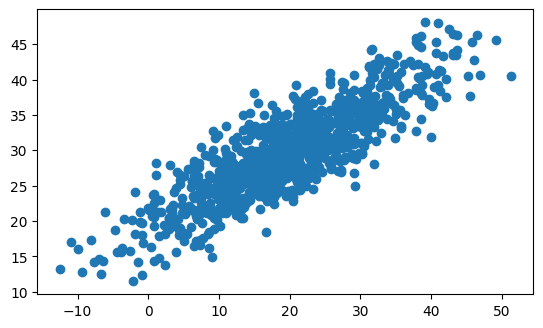

In [ ]:
fig, ax = plt.subplots(nrows =1, ncols = 1)
ax.scatter(X[0, :], X[1, :])
# getting the arrow
ax.arrow(
    b[0] - z1[0] * rho1,
    b[1] - z1[1] * rho1,
    2 * z1[0] * rho1,
    2 * z1[1] * rho1,
    color="black",
)
ax.arrow(
    b[0] - z2[0] * rho2,
    b[1] - z2[1] * rho2,
    2 * z2[0] * rho2,
    2 * z2[1] * rho2,
    color="black",
)
ax.set_aspect("equal")
# arrow to get the segments
#arrow ->

Perform PCA on the matrix $X$:

$\boldsymbol{\mu} = \frac{1}{n} \sum_{i=1}^{n} \mathbf{x}_i$

$\overline{X} = X - \boldsymbol{\mu} [1,\dots,1]$

$\overline{X} = U \Sigma V^T$


In [7]:
X_mean = np.mean(X, axis =1) # looping over each column to get the mean of that column, done by giving axis = 1
X_mean.shape
# X_bar = X - X_mean will throw error because of shape differences, so we should do broadcast
X_bar = X - X_mean[:, None]
U, s, VT = np.linalg.svd(X_bar, full_matrices=False) #full_matrices = False, since we discard unwanted data, singular columns and extra zeros
# U - has the principal directions

Finding the first two singular vectors, rescaled by the root of the sample variance

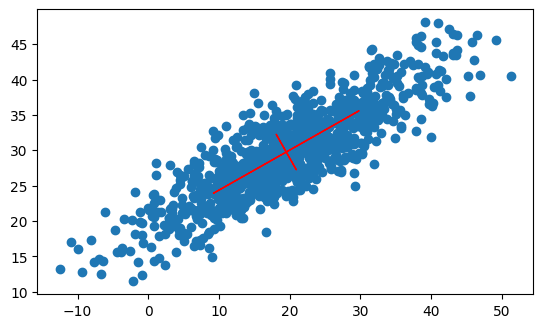

In [8]:
# SOLUTION-BEGIN
u1 = U[:, 0] #all rows in first column
u2 = U[:, 1]

r = s / np.sqrt(n_points -1)

fig, ax = plt.subplots(nrows=1, ncols=1)
ax.scatter(X[0, :], X[1, :])
ax.arrow(
    X_mean[0] - u1[0] * r[0], #here we don't know b, so we use an estimator that is X_mean
    X_mean[1] - u1[1] * r[0],
    2 * u1[0] * r[0],
    2 * u1[1] * r[0],
    color="red",
)
plt.arrow(
    X_mean[0] - u2[0] * r[1],
    X_mean[1] - u2[1] * r[1],
    2 * u2[0] * r[1],
    2 * u2[1] * r[1],
    color="red",
)
ax.set_aspect("equal")
# SOLUTION-END

Print and compare the real transformation directions ( 𝐳1,𝐳2 ) and the estimated ones ( 𝐮1,𝐮2 )

In [9]:
# SOLUTION-BEGIN
# real transformation directions
print(z1, z2)
# estimated transformation directions
print(u1, u2)
# SOLUTION-END

[0.8660254 0.5      ] [-0.5        0.8660254]
[-0.87010612 -0.49286442] [-0.49286442  0.87010612]


Compute the principal components of the data:

$\Phi = U^T \overline{X}$


In [10]:
Phi = np.matmul(U.transpose(), X - X_mean[:, None])

Make a scatterplot of the two first principal components ($\phi_1$, $\phi_2$), rescaled by the root of the sample variance


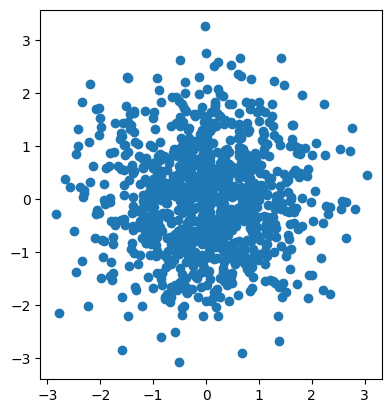

In [11]:
fig, ax = plt.subplots(nrows=1, ncols = 1)
ax.scatter(Phi[0, :] / r[0], Phi[1, :] / r[1])
ax.set_aspect("equal")

# Phi[0, :] -> first principal component is in the first row